# #1 Spatial Scores

## Purpose

Impute spatial scores for neural cells using Stereo-seq data from ["Chen et al. 2022"](https://doi.org/10.1016/j.cell.2022.04.003).

## Setup

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scanpy as sc
import seaborn as sns
import squidpy as sq
import anndata as ad
import shapely as shp
import shapely.geometry as geom
import geopandas as gpd
import numpy as np
import scipy as sp
import skiimage as ski
import numpy as np
import pandas as pd
import matplotlib as mpl
import sklearn as skl

from devmap.config import set_theme, get_paths, celltype_palette
from devmap.utils import save_plot, load_data

set_theme()
base_path, plots_path, results_path = get_paths("spatial_patterning")

## Load data

In [ ]:
tdata = load_data("log1p")
spatial = ad.read_h5ad(base_path / "data" / "E13.5_E1S3.MOSTA.h5ad")

Load manual cellxgene annotation of brain regions and midline

In [ ]:
annotation = pd.read_csv(results_path / "mosta_e13.5_annotation.csv", index_col=0)
spatial.obs["region"] = annotation["region"]
spatial.obs["midline"] = annotation["midline"]

## AP and DV Coordinates

In [ ]:
resolution = 1.0
margin = 10

# 1. Compute the overall midline
midline_mask = spatial.obs['midline'] == 'midline'
midline_coords = spatial[midline_mask].obsm['spatial']
midline_regions = spatial[midline_mask].obs['region'].values
anterior_center = spatial[spatial.obs['midline'] == 'anterior'].obsm['spatial'].mean(axis=0)
posterior_center = spatial[spatial.obs['midline'] == 'posterior'].obsm['spatial'].mean(axis=0)
midline_poly = geom.MultiPoint([geom.Point(xy) for xy in midline_coords]).buffer(15).buffer(-5)

minx, miny, maxx, maxy = midline_poly.bounds
x_coords = np.arange(minx - margin, maxx + margin, resolution)
y_coords = np.arange(miny - margin, maxy + margin, resolution)
xx, yy = np.meshgrid(x_coords, y_coords)

mask = shp.vectorized.contains(midline_poly, xx, yy).astype(np.float64)
dist = sp.ndimage.distance_transform_edt(mask)

def coord_to_idx(pt):
    col = int((pt[0] - (minx - margin)) / resolution)
    row = int((pt[1] - (miny - margin)) / resolution)
    row = np.clip(row, 0, dist.shape[0] - 1)
    col = np.clip(col, 0, dist.shape[1] - 1)
    return (row, col)

cost = dist.max() - dist + 1
cost[mask == 0] = 1e9

path_indices, _ = ski.graph.route_through_array(
    cost, coord_to_idx(anterior_center), coord_to_idx(posterior_center), fully_connected=True
)
path_indices = np.array(path_indices)

path_x = x_coords[0] + path_indices[:, 1] * resolution
path_y = y_coords[0] + path_indices[:, 0] * resolution

smooth_x = sp.ndimage.uniform_filter1d(path_x, size=30)
smooth_y = sp.ndimage.uniform_filter1d(path_y, size=30)
path_smooth = np.column_stack([smooth_x, smooth_y])

midline = geom.LineString(path_smooth)

# 2. Assign each midline path point to a region via nearest midline cell
tree = sp.spatial.cKDTree(midline_coords)
_, nearest_idx = tree.query(path_smooth)
path_regions = midline_regions[nearest_idx]

# 3. Split the path into region segments
region_midlines = {}
current_region = path_regions[0]
current_start = 0

for i in range(1, len(path_regions)):
    if path_regions[i] != current_region:
        coords = path_smooth[current_start:i]
        if len(coords) >= 2:
            if current_region not in region_midlines:
                region_midlines[current_region] = coords
            else:
                region_midlines[current_region] = np.vstack([region_midlines[current_region], coords])
        current_region = path_regions[i]
        current_start = i

coords = path_smooth[current_start:]
if len(coords) >= 2:
    if current_region not in region_midlines:
        region_midlines[current_region] = coords
    else:
        region_midlines[current_region] = np.vstack([region_midlines[current_region], coords])
        
region_midlines = {r: geom.LineString(c) for r, c in region_midlines.items() if len(c) >= 2}

# 4. Compute AP and DV scores
ap_scores = np.full(len(spatial), np.nan)
dv_scores = np.full(len(spatial), np.nan)

for region, region_line in region_midlines.items():
    region_mask = spatial.obs['region'].values == region
    region_coords = spatial[region_mask].obsm['spatial']
    
    projections = np.array([region_line.project(geom.Point(xy)) for xy in region_coords])
    
    # Map to global AP via position on the full midline
    region_start_global = midline.project(geom.Point(region_line.coords[0]))
    ap_scores[region_mask] = region_start_global + projections
    
    # DV: signed distance to the midline
    # For each cell, find the nearest point on the midline and compute
    # a signed distance using the local normal direction
    signed_dists = np.zeros(len(region_coords))
    for i, xy in enumerate(region_coords):
        pt = geom.Point(xy)
        nearest_pt = region_line.interpolate(projections[i])
        
        # Get local tangent direction at this point on the midline
        eps = 1.0
        d = projections[i]
        p1 = region_line.interpolate(max(d - eps, 0))
        p2 = region_line.interpolate(min(d + eps, region_line.length))
        tangent = np.array([p2.x - p1.x, p2.y - p1.y])
        tangent = tangent / (np.linalg.norm(tangent) + 1e-9)
        
        # Normal is perpendicular to tangent (rotate 90 degrees)
        normal = np.array([-tangent[1], tangent[0]])
        
        # Signed distance: positive if on the normal side, negative on the other
        delta = np.array([xy[0] - nearest_pt.x, xy[1] - nearest_pt.y])
        signed_dists[i] = np.dot(delta, normal)
    
    if "Spinal cord" in region:
        dv_scores[region_mask] = -signed_dists

# 5. Normalize AP and DV to [0, 1]
valid_ap = ~np.isnan(ap_scores)
ap_scores[valid_ap] = (ap_scores[valid_ap] - np.nanmin(ap_scores)) / (np.nanmax(ap_scores) - np.nanmin(ap_scores))
valid_dv = ~np.isnan(dv_scores)
dv_scores[valid_dv] = (dv_scores[valid_dv] - np.nanmin(dv_scores)) / (np.nanmax(dv_scores) - np.nanmin(dv_scores))
spatial.obs['ap_score'] = ap_scores
spatial.obs['dv_score'] = dv_scores

In [ ]:
sc.pl.spatial(spatial[spatial.obs["annotation"].isin(["Spinal cord","Brain"])], color = "dv_score", spot_size=5)
sc.pl.spatial(spatial[spatial.obs["annotation"].isin(["Spinal cord","Brain"])], color = "ap_score", spot_size=5)

## Spatially variable genes

In [8]:
spatial_neural = spatial[spatial.obs["annotation"].isin(["Spinal cord","Brain"])].copy()

Score genes

In [ ]:
def score_spatial_genes(adata, score_col='ap_score', n_neighbors=10):
    """Find genes varying that vary with a given score axis using Moran's I"""
    
    valid = ~np.isnan(adata.obs[score_col].values)
    adata_ap = adata[valid].copy()
    
    # Replace spatial coordinates with 1D AP score
    # so the neighbor graph reflects AP proximity, not 2D proximity
    ap = adata_ap.obs[score_col].values
    adata_ap.obsm['spatial'] = np.column_stack([ap, np.zeros_like(ap)])
    
    sq.gr.spatial_neighbors(adata_ap, n_neighs=n_neighbors, coord_type='generic')
    sq.gr.spatial_autocorr(adata_ap, mode='moran')
    adata.var["cov"] = adata.X.toarray().std(axis=0) / adata.X.toarray().mean(axis=0)
    
    result = adata_ap.uns['moranI'].copy()
    result = result.sort_values('I', ascending=False)
    result['cov'] = adata.var["cov"]
    
    return result
score_spatial_genes(spatial_neural, score_col='ap_score')

Check gene

/tmp/ipykernel_531450/2149849565.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(spatial_neural, color = "Hoxc6", spot_size=5, ncols=3)


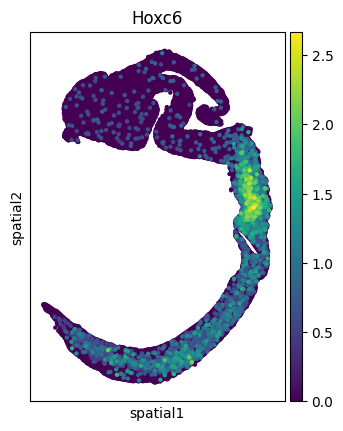

In [430]:
sc.pl.spatial(spatial_neural, color = "Hoxc6", spot_size=5, ncols=3)

Manually curated list

In [ ]:
expressed = spatial.var.query("total_counts > 1000").index.tolist()
ap_genes = [
    "Otx2", "Six3", "Foxg1", "Lhx2", "Emx1",
    "Dlx1","Dlx2","Nkx2-1","Lhx8","Arx","Lhx6",
    "Gbx2", "Fgf8", "En1", "En2", "Pax2", "Wnt1",
    "Mafb","Gata3",
    "Rarb", "Aldh1a2",
    "Meis1", "Meis2", "Pbx1",
    "Fezf2", "Irx3"
]
hox_genes = spatial.var_names[spatial.var_names.str.startswith("Hox")]
ap_genes = ap_genes + list(hox_genes)
ap_genes = [g for g in ap_genes if g in expressed]
dv_genes = [
    "Foxa2", "Shh", "Nkx2-2", "Nkx2-9", "Arx", "Lhx1", "Lhx5",
    "Olig2", "Nkx6-1", "Nkx6-2", "Mnx1", "Isl1", "Isl2",
    "Irx3", "Vsx2", "Dbx1", "Dbx2", "Evx1", "Evx2", "En1",
    "Pax3", "Pax7", "Msx1", "Msx2", "Atoh1", "Neurog1", "Neurog2",
    "Ascl1", "Ptf1a", "Lbx1", "Tlx3", "Lmx1b",
    "Gli1", "Gli2", "Gli3", "Prdm12",
    "Zic1", "Zic2", "Nkx1-2", "Hes5", "Sox2",
    "Olig3", "Wnt1", "Bmp4", "Bmp7", "Nog",
    "Sncg", "Prph","Npy","Nefm","Slit3","Zic4", "Chchd10","Uts2b"
]
dv_genes = [g for g in dv_genes if g in expressed]
gene_sets = {
    "ap": ap_genes,
    "dv": dv_genes}

Save gene sets

In [434]:
pd.Series(ap_genes).to_csv(results_path / "ap_genes.csv", index=False, header=False)
pd.Series(dv_genes).to_csv(results_path / "dv_genes.csv", index=False, header=False)

## Classifier

In [ ]:
def train_model(adata, genes, score_col='ap_score', n_trees=100, cv=5, random_state=0):
    # Get expression in valid cells
    valid = ~np.isnan(adata.obs[score_col].values)
    adata_valid = adata[valid]
    ap = adata_valid.obs[score_col].values
    used_genes = [g for g in genes if g in adata_valid.var_names]
    gene_idx = [list(adata_valid.var_names).index(g) for g in used_genes]
    X = adata_valid[:, gene_idx].X
    # Train model with 5-fold CV and get feature importance
    model = skl.ensemble.RandomForestRegressor(
        n_estimators=n_trees,
        random_state=random_state,
        n_jobs=-1
    )
    cv_splitter = skl.model_selection. KFold(n_splits=cv, shuffle=True, random_state=random_state)
    cv_scores = skl.model_selection.cross_val_score(model, X, ap, cv=cv_splitter, scoring='r2')
    oof_preds = skl.model_selection.cross_val_predict(model, X, ap, cv=cv_splitter, n_jobs=-1)
    model.fit(X, ap)
    # Get predictions and accuracy
    pred_series = pd.Series(index=adata.obs_names, dtype=float, name="predicted_score")
    pred_series.loc[adata_valid.obs_names] = oof_preds
    print(f"CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    return model, cv_scores, pred_series

In [ ]:
models = {}
cv_scores = {}
predictions = {}
for score in ['ap_score', 'dv_score']:
    print(f"Training model for {score}...")
    model, cv_score, pred_series = train_model(spatial_neural, ap_genes if score == 'ap_score' else dv_genes, score_col=score)
    models[score] = model
    cv_scores[score] = cv_score
    predictions[score] = pred_series
spatial_neural.obs["predicted_ap_score"] = predictions["ap_score"]
spatial.obs["predicted_ap_score"] = predictions["ap_score"]
spatial_neural.obs["predicted_dv_score"] = predictions["dv_score"]
spatial.obs["predicted_dv_score"] = predictions["dv_score"]

Save models and scores

In [ ]:
import pickle
with open(results_path / "ap_score_model.pkl", "wb") as f:
    pickle.dump(models['ap_score'], f)
with open(results_path / "dv_score_model.pkl", "wb") as f:
    pickle.dump(models['dv_score'], f)
spatial.obs[["region", "midline", "ap_score", "dv_score", "predicted_ap_score", 
    "predicted_dv_score"]].to_csv(results_path / "mosta_e13.5_annotation.csv")

## Segment neural ectoderm

In [ ]:
# Helper functions
def fill_holes(geom):
    if isinstance(geom, geom.MultiPolygon):
        return geom.MultiPolygon([geom.Polygon(p.exterior) for p in geom.geoms])
    elif isinstance(geom, geom.Polygon):
        return geom.Polygon(geom.exterior)
    return geom

def largest_polygon(geom):
    if isinstance(geom, geom.MultiPolygon):
        return max(geom.geoms, key=lambda p: p.area)
    return geom

# Build GeoDataFrame with centroids of the spinal cord cells
centers = gpd.GeoDataFrame(
    spatial_neural.obs,
    geometry=[geom.Point(xy) for xy in spatial_neural.obsm['spatial']]
)
# Merge into a single geometry
mask = centers['geometry'].buffer(1).union_all()
mask = fill_holes(geom.Polygon(mask) if mask.geom_type == 'Polygon' else mask)
mask = gpd.GeoSeries([mask]).buffer(.5).apply(fill_holes).buffer(-.5).iloc[0]
mask = largest_polygon(mask)
mask = fill_holes(mask)
mask = gpd.GeoSeries([mask]).buffer(.5).buffer(-.5).iloc[0]
mask = mask.simplify(tolerance=.5)

# Final GeoDataFrame with a single geometry
neural_segmentation = gpd.GeoDataFrame(
    {'annotation': ['Spinal cord']},
    geometry=[mask]
)

# Save the segmentation as GeoJSON
neural_segmentation.to_file(results_path / "neural_segmentation.geojson", driver="GeoJSON")

## Plot neural regions

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=600)
sc.pl.spatial(spatial[~spatial.obs.annotation.isin(["Brain","Spinal cord"])], color="annotation", 
              spot_size=3, ax=ax, show=False, alpha = .03, frameon=False)
sc.pl.spatial(spatial[spatial.obs.region.notnull()], color="region", spot_size=3, ax=ax, 
              show=False, frameon=False, palette=celltype_palette)
neural_segmentation.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
ax.invert_yaxis()
save_plot(plots_path / "spatial_annotated.svg", fig, rasterize=True)

## Plot spatial scores

AP score with local tangents

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(4, 4), dpi=600)
sc.pl.spatial(spatial[~spatial.obs.annotation.isin(["Brain", "Spinal cord"])],
    color="annotation",spot_size=3,ax=ax,show=False,alpha=.03,
    frameon=False,legend_loc=None)
sc.pl.spatial(
    spatial[spatial.obs.region.notnull()],color="ap_score",spot_size=3,
    show=False,cmap="Oranges_r",vmin=0,vmax=1,ax=ax)
neural_segmentation.plot(ax=ax, color="none", edgecolor="black", linewidth=2)

# Local tangents
perp_half_length = 50
eps = 1.0
for ap_target in [0.2, 0.4, 0.6, 0.8]:
    d = ap_target * midline.length
    center = midline.interpolate(d)
    p1 = midline.interpolate(max(d - eps, 0))
    p2 = midline.interpolate(min(d + eps, midline.length))
    tangent = np.array([p2.x - p1.x, p2.y - p1.y])
    tangent = tangent / (np.linalg.norm(tangent) + 1e-9)
    normal = np.array([-tangent[1], tangent[0]])
    x0 = center.x - perp_half_length * normal[0]
    y0 = center.y - perp_half_length * normal[1]
    x1 = center.x + perp_half_length * normal[0]
    y1 = center.y + perp_half_length * normal[1]
    ax.plot([x0, x1], [y0, y1],
            linestyle="--", color="black", linewidth=1.5)
ax.invert_yaxis()

save_plot(plots_path / "spatial_ap_score.svg", fig, rasterize=True)

DV score

In [ ]:
fig, ax = plt.subplots(figsize=(4, 4), dpi=600)
sc.pl.spatial(spatial[~spatial.obs.annotation.isin(["Brain","Spinal cord"])], 
              color="annotation", spot_size=3, ax=ax, show=False, alpha = .03, frameon=False, legend_loc = None)
sc.pl.spatial(spatial[spatial.obs.region.notnull()], color="dv_score", spot_size=3, 
              show=False, cmap = "Purples_r", ax = ax)
neural_segmentation.plot(ax=ax, color="none", edgecolor="black", linewidth=2)
ax.invert_yaxis()
save_plot(plots_path / "spatial_dv_score.svg", fig, rasterize=True)

## Plot cross validation scores

Spatial

In [ ]:
for score, cmap in [("ap", "Oranges_r"), ("dv", "Purples_r")]:
    fig, ax = plt.subplots(figsize=(4, 4), dpi=600)
    sc.pl.spatial(
        spatial[~spatial.obs.annotation.isin(["Brain", "Spinal cord"])],
        color="annotation",spot_size=3,ax=ax,show=False,
        alpha=.03,frameon=False,legend_loc=None)
    sc.pl.spatial(spatial_neural,color=f"predicted_{score}_score",
        spot_size=1.2,show=False,cmap=cmap,ax=ax,vmin=0,vmax=1,sort_order=False)
    neural_segmentation.plot(ax=ax, color="none", edgecolor="black", linewidth=2)
    ax.invert_yaxis()
    save_plot(plots_path / f"spatial_predicted_{score}_score.svg",
        fig,rasterize=True)

Scatterplot

In [ ]:
for score, color in [("ap", "#fd8c3b"), ("dv", "#7262ac")]:
    df = spatial_neural.obs if score == "ap" else spatial_neural.obs.query("dv_score.notnull()")
    fig, ax = plt.subplots(figsize=(1.8, 1.8), dpi=600)
    sns.scatterplot(data=df,x=f"{score}_score",y=f"predicted_{score}_score",
        s=.5,alpha=.5,color=color,linewidth=0,ax=ax)
    ax.plot([0, 1], [0, 1], color="black", linestyle="--")
    r2 = np.corrcoef(df[f"{score}_score"], df[f"predicted_{score}_score"])[0, 1] ** 2
    ax.text(0.05, 0.9, f"$R^2$ = {r2:.3f}", transform=ax.transAxes)
    save_plot(plots_path / f"pred_{score}_score_correlation.svg",
        fig,rasterize=True)

## Spatially predictive gene heatmaps

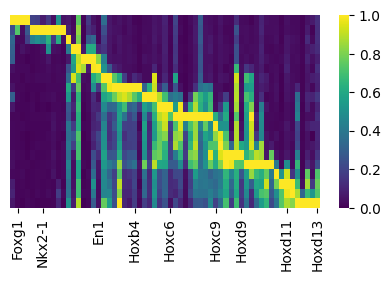

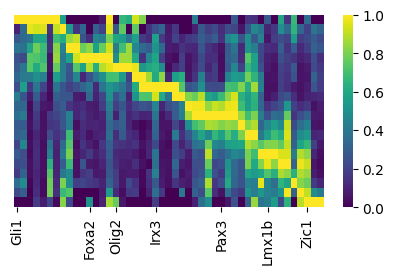

In [ ]:
labels = {"ap": ["Foxg1","Nkx2-1","En1","Hoxb4","Hoxc6",'Hoxc9',"Hoxd9","Hoxd11","Hoxd13"], 
          "dv": ["Foxa2","Olig2","Irx3","Pax3","Gli1",'Lmx1b',"Zic1"]}

for axis in ["ap","dv"]:
    spatial_neural.obs[f"{axis}_bin"] = pd.cut(
        spatial_neural.obs[f"{axis}_score"], bins=20, labels=False
    )

    expression = sc.get.aggregate(
        spatial_neural[
            spatial_neural.obs[f"{axis}_bin"].notnull(),
            gene_sets[axis]
        ],
        by=f"{axis}_bin",
        func="mean",
    )

    expression = pd.DataFrame(
        expression.layers["mean"],
        index=expression.obs_names,
        columns=gene_sets[axis],
    )
    expression = expression / expression.max()

    gene_peak_bin = expression.idxmax(axis=0)
    bin_to_pos = {bin_name: i for i, bin_name in enumerate(expression.index)}
    gene_peak_pos = gene_peak_bin.map(bin_to_pos)
    ordered_genes = gene_peak_pos.sort_values().index.tolist()

    fig, ax = plt.subplots(figsize=(5, 2.5))
    sns.heatmap(
        expression[ordered_genes],
        ax=ax,
        xticklabels=False,
        yticklabels=False,
        cmap="viridis",
    )

    # Label only selected genes
    selected_genes = labels[axis]
    tick_pos = [ordered_genes.index(g) + 0.5 for g in selected_genes if g in ordered_genes]
    tick_lab = [g for g in selected_genes if g in ordered_genes]

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lab, rotation=90)

    save_plot(plots_path / f"{axis}_gene_heatmap.svg", fig)

## Example spatially predictive genes

In [ ]:
for gene in ["Hoxc6", "Lmx1b","Uts2b", "Hoxd11","Foxg1"]:
    fig, axes = plt.subplots(2, 1, figsize=(4, 8), dpi=600)
    sc.pl.spatial(spatial[~spatial.obs.annotation.isin(["Brain","Spinal cord"])], color="annotation", spot_size=3, ax=axes[0], 
                  show=False, alpha = .03, frameon=False, legend_loc = None)
    sc.pl.spatial(spatial_neural, color=gene, spot_size=3, ax=axes[0], show=False, vmax = 2.5)
    neural_segmentation.plot(ax=axes[0], color="none", edgecolor="black", linewidth=2)
    axes[0].invert_yaxis()
    sc.pl.umap(tdata, color=gene, ax=axes[1], show=False, vmax = 2.5)
    save_plot(plots_path / f"{gene}_spatial_umap.svg", fig, rasterize=True)

## Predicted score

In [ ]:
tdata.obs["ap_score"] = models["ap_score"].predict(tdata[:, ap_genes].X)
tdata.obs["dv_score"] = models["dv_score"].predict(tdata[:, dv_genes].X)
spinal_type = ["Spinal cord (cervical)","Spinal cord (thoracic)","Spinal cord (lumbar)","Spinal cord (sacral)","V1 interneuron","V2 interneuron","V3 interneuron","Dl1 interneuron","Somatic motor neuron",
                "Floor plate (posterior)","Dl2-6 interneuron","V0 interneuron","Spinal cord","Axial progenitor","Dorsal root ganglion neuron","Roof plate (posterior)"]
tdata.obs["neural_ap_score"] = tdata.obs["ap_score"]
tdata.obs.loc[~tdata.obs.lineage.isin(["Neural ectoderm","Neural crest"]), "neural_ap_score"] = pd.NA
tdata.obs.loc[~tdata.obs.cell_subtype.isin(spinal_type), "dv_score"] = pd.NA
cmaps = {"neural_ap": "Oranges_r","ap": "Oranges_r", "dv": "Purples_r"}

UMAP

In [ ]:
for score in ["neural_ap", "dv"]:
    fig, ax = plt.subplots(figsize=(4, 4), dpi=600)
    sc.pl.umap(
        tdata,
        color=f"{score}_score",
        ax=ax,
        show=False,
        frameon=False,
        cmap=cmaps[score],
        title="",
        vmin=0,
        vmax=1,
    )
    save_plot(plots_path / f"umap_{score}_score.svg", fig, rasterize=True)

AP score boxplot

In [ ]:
order = ["Telencephalon","Diencephalon","Midbrain","Hindbrain (r1)","Hindbrain (r2-r4)","Hindbrain (r5-r8)",
        "Spinal cord (cervical)","Spinal cord (thoracic)","Spinal cord (lumbar)","Spinal cord (sacral)"]
df = tdata.obs.query("cell_type.isin(@order)").copy()
df["cell_type"] = df["cell_type"].cat.remove_unused_categories()
df["mean_ap"] = df.groupby("cell_type")["ap_score"].transform("mean")
norm = mpl.colors.Normalize(vmin=0, vmax=1)
fig, ax = plt.subplots(figsize=(1.6, 1.6), dpi=600)
sns.boxplot(data = df, y="cell_type", x="ap_score",ax = ax,hue = "mean_ap", palette="Oranges_r",
            order=df.groupby("cell_type")["ap_score"].mean().sort_values().index, hue_norm=norm, 
            showfliers=False, linecolor="black", linewidth=.5, legend = False)
# rotate x labels
plt.yticks(fontsize=8)
plt.xlim(0, 1)
save_plot(plots_path / "ap_score_boxplot.svg", fig, rasterize=False)

DV score boxplot

In [ ]:
order = ["V3 interneuron","V2 interneuron","V1 interneuron","Dl1 interneuron","Somatic motor neuron",
        "Floor plate (posterior)","Dl2-6 interneuron","V0 interneuron","Roof plate (posterior)"]
df = tdata.obs.query("cell_subtype.isin(@order) & dv_score.notnull()").copy()
df["cell_subtype"] = df["cell_subtype"].cat.remove_unused_categories()
df["mean_dv"] = df.groupby("cell_subtype")["dv_score"].transform("mean")
norm = mpl.colors.Normalize(vmin=0, vmax=1)
fig, ax = plt.subplots(figsize=(1.6, 1.6), dpi=600)
sns.boxplot(data = df, y="cell_subtype", x="dv_score",ax = ax,hue = "mean_dv", palette="Purples_r",
            order=df.groupby("cell_subtype")["dv_score"].mean().sort_values().index, hue_norm=norm, 
            showfliers=False, linecolor="black", linewidth=.5, legend = False)
# rotate x labels
plt.yticks(fontsize=8)
save_plot(plots_path / "dv_score_boxplot.svg", fig, rasterize=True)

## Save results

In [742]:
tdata.obs[["ap_score", "dv_score","neural_ap_score"]].to_csv(results_path / "spatial_scores.csv")